# RAMIFY — Version 1 (actions) · le livrable, section par section du brief

> **Ce notebook EST la commande Ramify (Semaines 3-4), Version 1.** Il suit le brief
> (`0.Notion_Ramify.pdf`) *mot pour mot* : stratégie d'entrée/sortie → sélection annuelle des K congressmen
> → critère de sélection → filtre commissions → métriques. La **V2 (ETF)** est dans `RAMIFY_V2_ETF.ipynb`.
> La recherche au-delà de la demande (exploration, chasse au signal, approfondissement) est dans `SUPP_*`.
>
> **V1 = actions directes** : on trade le ticker exact déclaré. Sert à *valider le signal brut* et à
> *construire les track records individuels* (brief, §Version 1). Données : caches Quiver 2014→2026.


In [1]:
import sys, os, warnings; warnings.filterwarnings('ignore')
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = os.path.join(base, '00. S3S4 en cours')
    if os.path.exists(os.path.join(p, 'data.py')): S3 = p; break
sys.path.insert(0, S3); os.chdir(S3)
import numpy as np, pandas as pd
import data, prices, portfolio, evaluate, selection
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4.2)

# Helpers d'évaluation (réutilisés par RAMIFY_V2 aussi)
def ann_stats(daily):
    d = daily.dropna(); yrs = len(d)/252
    cagr = (1+d).prod()**(1/yrs) - 1; vol = d.std()*np.sqrt(252)
    sh = d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan
    cum = (1+d).cumprod(); dd = (cum/cum.cummax()-1).min()
    return {'CAGR':cagr,'vol':vol,'sharpe':sh,'maxDD':dd}
def bench_daily(price, idx):
    return price.reindex(idx).ffill().pct_change().fillna(0.0)
def fmt(df, index=True):   # formatage colonne par colonne (% vs ratio vs entier)
    pct={'CAGR','vol','maxDD','alpha_vs_SPY','alpha_FF','alpha'}; ratio={'sharpe','t','beta'}
    f={}
    for c in df.columns:
        if c in pct: f[c]=lambda x:f'{x:+.2%}'
        elif c in ratio: f[c]=lambda x:f'{x:.2f}'
        elif c in {'K','n_pos','n'}: f[c]=lambda x:f'{int(x):d}'
    return df.to_string(index=index, formatters=f)
print('moteur importé depuis :', S3)

moteur importé depuis : /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours


## 1. Données + la « série de trades » de chaque membre

Pour scorer les congressmen (cf. §3), on a besoin du **rendement réalisé de chaque trade** tel que la
stratégie le vit : entrée `filed`+1 jour ouvré, sortie = vente correspondante sinon +12 mois, rendement
**anormal vs SPY**. `selection.with_realized` calcule ça (`tret`) + la date de sortie (`exit_d`, pour ne
scorer que les trades **clôturés** → aucun look-ahead). On affiche couverture prix et part survivorship.

In [2]:
df = data.load_transactions(2014, 2026)
buys = data.buy_signals(df).copy()
all_tk = sorted(buys['ticker'].dropna().unique())
panel = prices.load_panel(all_tk); spy = prices.get_spy(); factors = prices.get_factors()
buys = selection.with_realized(buys, df, panel, spy, horizon_months=12)   # ajoute tret + exit_d
com = selection.load_committees()

print(f"achats Quiver 2014+ : {len(buys):,}  |  membres : {buys['bioguide'].nunique()}")
print(f"prix en cache : {panel.shape[1]:,}/{len(all_tk):,} tickers  |  série de trades évaluable : "
      f"{buys['tret'].notna().mean():.1%}")
print(f"tickers délistés/sans prix : {len(all_tk)-panel.shape[1]:,} → SURVIVORSHIP = borne haute (rendements optimistes)")
print(f"membres en commission clé (Finance/Defense/Intelligence) : "
      f"{sum(selection.is_key(b, com) for b in buys['bioguide'].unique())}/{buys['bioguide'].nunique()}")

achats Quiver 2014+ : 56,877  |  membres : 251
prix en cache : 2,171/3,797 tickers  |  série de trades évaluable : 80.8%
tickers délistés/sans prix : 1,626 → SURVIVORSHIP = borne haute (rendements optimistes)
membres en commission clé (Finance/Defense/Intelligence) : 66/251


## 2. Stratégie d'entrée et de sortie (brief, *copy trading pur*)

> *On entre dès qu'une disclosure « Purchase » est publiée, à la `disclosure_date` (+1 jour ouvré, sans
> look-ahead). On sort à la vente correspondante du même congressman sur le même ticker, sinon **12 mois**
> après l'entrée.* `portfolio.build_positions` applique exactement cette hiérarchie. Exemple concret :

In [3]:
# Les DEUX règles de sortie (brief) : vente correspondante, sinon +12 mois forcé
bd = pd.tseries.offsets.BDay(1); H = pd.DateOffset(months=12)
def show_trade(row):
    entry = (row['filed'] + bd).date()
    rule = 'sortie à la VENTE correspondante' if row['exit_d'] < row['filed'] + H else 'sortie FORCÉE +12 mois'
    print(f"  {row['name']} achète {row['ticker']} (disclosure {row['filed'].date()}) → entrée {entry} "
          f"(+1 ouvré) → sortie {pd.Timestamp(row['exit_d']).date()}  [{rule}]")
sample = buys[buys['filed'].dt.year.between(2019, 2023)]
ex_sale = sample[sample['exit_d'] < sample['filed'] + pd.DateOffset(months=11)].head(1)
ex_hold = sample[sample['exit_d'] >= sample['filed'] + H].head(1)
print("Exemples (brief — chaque achat = une observation entrée→sortie explicite) :")
for e in [ex_sale, ex_hold]:
    if len(e): show_trade(e.iloc[0])

Exemples (brief — chaque achat = une observation entrée→sortie explicite) :
  Michael C. Burgess achète BX (disclosure 2023-12-18) → entrée 2023-12-19 (+1 ouvré) → sortie 2024-01-22  [sortie à la VENTE correspondante]
  Debbie Dingell achète MDT (disclosure 2023-12-14) → entrée 2023-12-15 (+1 ouvré) → sortie 2024-12-14  [sortie FORCÉE +12 mois]


## 3. Sélection annuelle des K congressmen + critère (brief, §Sélection / §Intuition)

**Critère (brief)** : *le hit rate ne capture pas la magnitude ; le return moyen est sensible aux outliers ;
le **Sharpe sur la série de trades** est le plus robuste pour comparer des fréquences différentes ; l'alpha
vs SPX est ce qui compte.* On classe donc par **Sharpe de la série de trades réalisés**, **rétréci vers la
moyenne du groupe** (Mauboussin — un membre « chanceux » sur 11 trades ne double pas un régulier) avec une
**exploration UCB1** (Sutton & Barto, ch. 2 — confiance dynamique / bandit). **Éligible** = ≥10 trades
**clôturés**. **Filtre commissions** : **≥ la moitié des K** en Finance/Defense/Intelligence (brief).

In [4]:
# Pourquoi le Sharpe : un même classement par 3 critères (fin 2022, trades clôturés) → têtes différentes
cl = buys[(buys['exit_d']<=pd.Timestamp(2022,12,31)) & buys['tret'].notna()]
g = cl.groupby('bioguide')['tret']; el = g.size()[g.size()>=10].index
tab = pd.DataFrame({'n':g.size(),'hit':cl.groupby('bioguide')['win'].mean(),
                    'ret_moy':g.mean(),'sharpe':g.mean()/g.std()}).loc[el]
tab['name'] = [buys.drop_duplicates('bioguide').set_index('bioguide')['name'].get(b,b) for b in tab.index]
print("Top-3 selon chaque critère (fin 2022) — le Sharpe arbitre fréquence vs magnitude :")
for c in ['hit','ret_moy','sharpe']:
    top = tab.sort_values(c, ascending=False).head(3)
    print(f"  par {c:8s}: " + ", ".join(f"{n} ({v:.2f})" for n,v in zip(top['name'], top[c])))

Top-3 selon chaque critère (fin 2022) — le Sharpe arbitre fréquence vs magnitude :
  par hit     : Michael Garcia (0.92), Adam Kinzinger (0.72), Justin Amash (0.69)
  par ret_moy : Brenda Lulenar Lawrence (0.60), Michael Garcia (0.28), John Curtis (0.16)
  par sharpe  : Michael Garcia (0.59), Justin Amash (0.59), Brenda Lulenar Lawrence (0.47)


In [5]:
# Tableau de score complet (Sharpe rétréci + UCB) pour la sélection fin-2022 → appliquée à 2023
sc22 = selection.member_scores(buys, com, 2022).head(10)[['name','n','sharpe_brut','shrunk','ucb','score','key']]
print("Scoreboard fin-2022 (top 10 éligibles, trades clôturés) :")
print(sc22.to_string(index=False, float_format=lambda x: f'{x:6.3f}'))

K = 6   # valeur médiane a priori de la grille {4..10} pour les illustrations (pas choisie pour la perf)
sels = selection.selections_by_year(buys, com, K=K)
name_of = buys.drop_duplicates('bioguide').set_index('bioguide')['name']
print(f"\nSélection annuelle rolling (K={K}, ≥{int(np.ceil(K/2))} en commission clé) — appliquée à Y+1 :")
for y in range(2017, 2026):
    print(f"  fin {y} → suivis en {y+1} : " + ", ".join(name_of.get(b,b) for b in sels[y]))

Scoreboard fin-2022 (top 10 éligibles, trades clôturés) :
                   name  n  sharpe_brut  shrunk    ucb  score   key
         Michael Garcia 13        0.590   0.319  0.444  0.762 False
           Justin Amash 16        0.589   0.349  0.400  0.749 False
Brenda Lulenar Lawrence 12        0.470   0.241  0.462  0.703 False
           Cheri Bustos 13        0.378   0.199  0.444  0.642 False
        Deborah K. Ross 12        0.347   0.174  0.462  0.636 False
      Frank A. Lobiondo 18        0.391   0.239  0.377  0.617 False
           Kathy Castor 43        0.464   0.370  0.244  0.614 False
         Adam Kinzinger 18        0.331   0.201  0.377  0.578 False
        Susan W. Brooks 12        0.233   0.111  0.462  0.573 False
 Michael G. Fitzpatrick 18        0.302   0.182  0.377  0.559 False



Sélection annuelle rolling (K=6, ≥3 en commission clé) — appliquée à Y+1 :
  fin 2017 → suivis en 2018 : David Perdue, Michael G. Fitzpatrick, Thomas R. Carper, Kathy Castor, David B. Mckinley, John F. Reed
  fin 2018 → suivis en 2019 : Barbara J  Comstock, Josh Gottheimer, Michael G. Fitzpatrick, Kathy Castor, Frank A. Lobiondo, David Perdue
  fin 2019 → suivis en 2020 : Jerry Moran, Frank A. Lobiondo, Roger W. Marshall, Michael G. Fitzpatrick, Ed Perlmutter, Susie Lee
  fin 2020 → suivis en 2021 : Kelly Loeffler, Brenda Lulenar Lawrence, Roger W. Marshall, Justin Amash, Frank A. Lobiondo, Cheri Bustos
  fin 2021 → suivis en 2022 : Michael Garcia, Thomas R. Suozzi, Justin Amash, Brenda Lulenar Lawrence, Nancy Pelosi, Cheri Bustos
  fin 2022 → suivis en 2023 : Michael Garcia, Justin Amash, Brenda Lulenar Lawrence, Cheri Bustos, Deborah K. Ross, Frank A. Lobiondo
  fin 2023 → suivis en 2024 : Dan Sullivan, Justin Amash, Brenda Lulenar Lawrence, Cheri Bustos, Frank A. Lobiondo, Kathy Ca

## 4. Walk-forward V1 vs benchmarks (à K=6, illustration)

On ne garde que les achats d'un membre **l'année où il était sélectionné** (sélection sur les trades
clôturés de l'année précédente → walk-forward strict). Positions à 12 mois, **nettes de 20 bps**.
Benchmarks : **SPY** (cap-weight), **RSP** (équipondéré) et **60/40** (SPY+AGG). *Les positions des
congressmen non reconduits sont laissées courir jusqu'à leur sortie naturelle (brief).*

Walk-forward V1 — K=6, 1391 positions, 13.0 ans :
                  CAGR     vol sharpe   maxDD alpha_vs_SPY
V1 (size, net)  +9.40% +22.19%   0.52 -47.83%       -4.73%
SPY            +14.13% +16.99%   0.86 -33.72%       +0.00%
RSP            +11.69% +17.40%   0.72 -39.04%       -2.43%
60/40           +9.50% +10.58%   0.91 -21.72%       -4.62%



Alpha vs SPX, FF-Carhart (isole le beta marché/tech) : +0.72%/an  t=0.14  | beta marché=0.79


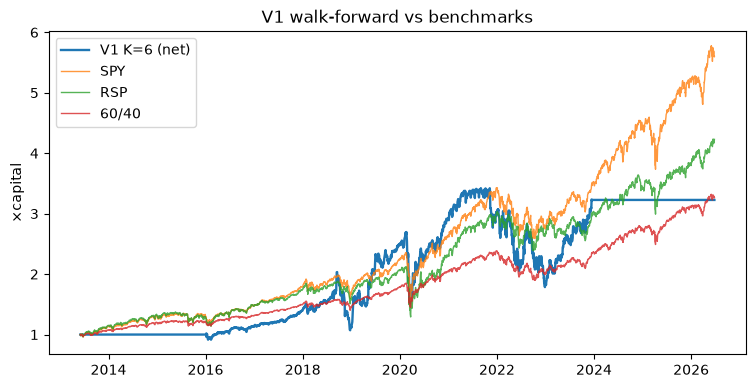

In [6]:
etfp = prices.load_panel(["XLE","XLB","XLI","XLY","XLP","XLV","XLF","XLK","XLC","XLU","XLRE","RSP","AGG"])
pos = portfolio.build_positions(selection.gate_buys(buys, sels), df, horizon_months=12)
d_v1 = portfolio.run_portfolio(pos, panel, weighting='size', cost_bps=20)['net']
idx = d_v1.index
b_spy, b_rsp = bench_daily(spy, idx), bench_daily(etfp['RSP'], idx)
b_6040 = 0.6*b_spy + 0.4*bench_daily(etfp['AGG'], idx)

rows = {'V1 (size, net)':ann_stats(d_v1),'SPY':ann_stats(b_spy),'RSP':ann_stats(b_rsp),'60/40':ann_stats(b_6040)}
tbl = pd.DataFrame(rows).T; tbl['alpha_vs_SPY'] = tbl['CAGR'] - ann_stats(b_spy)['CAGR']
print(f"Walk-forward V1 — K={K}, {len(pos)} positions, {len(idx)/252:.1f} ans :")
print(fmt(tbl))
fa = evaluate.factor_alpha(d_v1, factors)
print(f"\nAlpha vs SPX, FF-Carhart (isole le beta marché/tech) : {fa['alpha_annuel']:+.2%}/an  "
      f"t={fa['alpha_t']:.2f}  | beta marché={fa['beta_marche']:.2f}")

eq = (1+d_v1).cumprod()
plt.plot(eq.index, eq, label=f'V1 K={K} (net)', lw=1.7)
for lab,b in [('SPY',b_spy),('RSP',b_rsp),('60/40',b_6040)]:
    plt.plot(idx,(1+b).cumprod(),label=lab,lw=1,alpha=.8)
plt.legend(); plt.title('V1 walk-forward vs benchmarks'); plt.ylabel('×capital'); plt.show()

## 5. Grille K ∈ {4,6,8,10} + Deflated Sharpe (brief : *K à tester, typiquement 4-10*)

On rapporte **toutes** les valeurs (pas de cherry-pick). Le **Deflated Sharpe** (López de Prado) pénalise le
nombre de configs essayées (ici 4 K) : un Sharpe « gagnant » par chance ne survit pas.

In [7]:
grid, series = [], {}
for K_ in [4,6,8,10]:
    s = selection.selections_by_year(buys, com, K=K_)
    p = portfolio.build_positions(selection.gate_buys(buys, s), df, horizon_months=12)
    dd = portfolio.run_portfolio(p, panel, weighting='size', cost_bps=20)['net']
    series[K_] = dd; st = ann_stats(dd); fa_ = evaluate.factor_alpha(dd, factors)
    grid.append({'K':K_,'n_pos':len(p),'CAGR':st['CAGR'],'sharpe':st['sharpe'],'maxDD':st['maxDD'],
                 'alpha_FF':fa_['alpha_annuel'],'t':fa_['alpha_t'],'alpha_vs_SPY':st['CAGR']-ann_stats(b_spy)['CAGR']})
G = pd.DataFrame(grid); print(fmt(G, index=False))
dsh = {k:(v.mean()/v.std()) for k,v in series.items() if v.std()>0}
best = max(dsh, key=dsh.get); sr_std = float(np.std(list(dsh.values()), ddof=1))
dsr = evaluate.deflated_sharpe(series[best], sr_std_daily=sr_std, n_trials=len(series))
print(f"\nMeilleur K (Sharpe brut) = {best} (Sharpe {ann_stats(series[best])['sharpe']:.2f}) | "
      f"Deflated Sharpe = {dsr:.2f} | SPY Sharpe = {ann_stats(b_spy)['sharpe']:.2f}")
print("Lecture : la sélection ajoute un alpha actions positif mais NON significatif (t<1) ; aucun K ne bat")
print("le Sharpe de SPY. Le DSR dit seulement que le flux n'est pas un pur artefact de la grille.")

 K n_pos    CAGR sharpe   maxDD alpha_FF    t alpha_vs_SPY
 4   735 +10.24%   0.56 -48.38%   +1.74% 0.33       -3.89%
 6  1391  +9.40%   0.52 -47.83%   +0.72% 0.14       -4.73%
 8  1652 +13.29%   0.71 -48.05%   +3.97% 0.88       -0.84%
10  2139 +12.55%   0.68 -47.99%   +3.66% 0.83       -1.58%

Meilleur K (Sharpe brut) = 8 (Sharpe 0.71) | Deflated Sharpe = 0.99 | SPY Sharpe = 0.86
Lecture : la sélection ajoute un alpha actions positif mais NON significatif (t<1) ; aucun K ne bat
le Sharpe de SPY. Le DSR dit seulement que le flux n'est pas un pur artefact de la grille.


## 6. Métriques niveau-trade « façon Ramify » (V1, walk-forward K=6)

Hit rate, gain/perte moyens, **profit factor**, espérance — sur les rendements **anormaux** des positions
réellement prises.

In [8]:
tr_v1 = evaluate.trade_returns(pos, panel, spy)
st = evaluate.trade_stats(tr_v1)
print("Métriques niveau-trade — V1 :")
for k,v in st.items(): print(f"  {k:16s}: {v:+.3f}" if isinstance(v,float) else f"  {k:16s}: {v}")
print("\nLecture : hit-rate < 50 % et MÉDIANE négative, mais profit factor et espérance > 0 → l'« edge »")
print("vient de quelques gros gagnants (queue droite), pas du taux de réussite (typique du Congrès).")

Métriques niveau-trade — V1 :
  n               : 1075
  hit_rate        : +0.476
  avg_win         : +0.263
  avg_loss        : -0.163
  profit_factor   : +1.470
  esperance_abn   : +0.040
  mediane_abn     : -0.008

Lecture : hit-rate < 50 % et MÉDIANE négative, mais profit factor et espérance > 0 → l'« edge »
vient de quelques gros gagnants (queue droite), pas du taux de réussite (typique du Congrès).


## 7. Track records individuels (brief : *V1 sert à les construire*) + persistance

Sharpe / espérance par congressman, et le test décisif : la performance **persiste-t-elle** hors-échantillon
(2020-22 → 2023-25) ? Un renversement = la sélection capte de la **chance** (De Prado).

In [9]:
by = buys.dropna(subset=['tret']).groupby('bioguide')
rec = pd.DataFrame({'n':by.size(),'abn_moy':by['tret'].mean(),
                    'sharpe':by['tret'].mean()/by['tret'].std(),'hit':by['win'].mean()})
rec['name'] = [name_of.get(b,b) for b in rec.index]; rec = rec[rec['n']>=10].sort_values('abn_moy', ascending=False)
print("TOP 6 (rendement anormal réalisé moyen/trade, ≥10 trades) :")
print(rec.head(6)[['name','n','abn_moy','sharpe','hit']].to_string(index=False, float_format=lambda x:f'{x:6.3f}'))
print("\nBOTTOM 6 :")
print(rec.tail(6)[['name','n','abn_moy','sharpe','hit']].to_string(index=False, float_format=lambda x:f'{x:6.3f}'))

def wmean(lo,hi):
    s = buys[(buys['filed'].dt.year>=lo)&(buys['filed'].dt.year<=hi)].dropna(subset=['tret'])
    return s.groupby('bioguide')['tret'].agg(['mean','size'])
A,B = wmean(2020,2022), wmean(2023,2025)
top_is = A[A['size']>=10].sort_values('mean',ascending=False).head(10)
j = top_is.join(B['mean'], rsuffix='_oos')
print(f"\nPersistance — top-10 IN-SAMPLE 2020-22 : {top_is['mean'].mean():+.2%}  →  OOS 2023-25 : "
      f"{j['mean_oos'].mean():+.2%}  (renversement = sur-apprentissage)")

TOP 6 (rendement anormal réalisé moyen/trade, ≥10 trades) :
                    name   n  abn_moy  sharpe    hit
 Brenda Lulenar Lawrence  12    0.598   0.470  0.583
         Ashley B. Moody  15    0.462   0.484  0.600
            Dan Sullivan  39    0.419   0.635  0.692
              Angus King  33    0.239   0.283  0.485
Debbie Wasserman Schultz  31    0.212   0.232  0.516
               Tim Moore 132    0.204   0.270  0.697

BOTTOM 6 :
                          name  n  abn_moy  sharpe    hit
             John Hickenlooper 32   -0.153  -0.382  0.438
                  John Mcguire 10   -0.171  -0.848  0.100
                David A. Trott 58   -0.180  -1.106  0.121
                Tom Malinowski 90   -0.207  -0.618  0.300
Charles J. "Chuck" Fleischmann 10   -0.224  -0.444  0.200
            David H. McCormick 22   -0.417  -5.760  0.000

Persistance — top-10 IN-SAMPLE 2020-22 : +22.78%  →  OOS 2023-25 : +3.81%  (renversement = sur-apprentissage)


## 8. Références appliquées + synthèse V1

| Référence (brief) | Où elle agit dans CE notebook |
|---|---|
| **Mauboussin**, *The Success Equation* | §3 — Sharpe **rétréci** vers la moyenne du groupe (skill vs luck, séries courtes) |
| **Sutton & Barto**, *RL* ch. 2 | §3 — **UCB1** (confiance dynamique / bandit) dans le score de sélection |
| **Grinold & Kahn**, *Active PM* | borne IR=IC·√breadth — appliquée dans `SUPP_C` (signal à peu d'obs/personne) |
| **De Prado**, *Advances in Fin. ML* | §5 — **Deflated Sharpe** comptant la grille K ; §7 persistance OOS |
| Ziobrowski / Karadas / Eggers-Hainmueller | calibrage des attentes (cf. `STRATEGIE_ANALYSE.md`) |

**Synthèse V1 (actions)** : la stratégie *spécifiée* — sélection annuelle par Sharpe rétréci de la série de
trades + filtre commissions — produit un **alpha actions positif mais NON significatif** (meilleur K=8 :
≈ +4 %/an, *t* < 1) et un **Sharpe sous celui de SPY** ; **pas de persistance** des meilleurs membres
hors-échantillon ; au niveau trade, une **loterie à queue droite** (hit-rate < 50 %, profit factor ≈ 1). La
V1 *valide* qu'il existe un faible signal idiosyncratique au niveau **action** — la **`RAMIFY_V2_ETF`**
mesure ce qu'il en reste une fois traduit en **ETF sectoriels** (la version intégrable Ramify).